## Linear Regression Evaluation

### Load Dependencies

In [56]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import pickle

### Load Regression Model

In [57]:
filename = "linear_model1.sav"
model_A = pickle.load(open(filename, 'rb'))

### Load another Model for comparative study

In [58]:
filename = "linear_model2.sav"
model_B = pickle.load(open(filename, 'rb'))

### Store Model as Variable

In [59]:
y_col = "win%"
testing_data = pd.read_csv("2.4.1.testing_data.csv")

# Define different x columns for each model
x_cols = {"Model A": "avg_kill_per_rnd", "Model B": "dmg_indicator"}

# Prepare test data for each model
test_data = {}
for model_name, x_col in x_cols.items():
    try:
        if x_col not in testing_data.columns:
            print(f"Error: '{x_col}' column not found")
        elif y_col not in testing_data.columns:
            print(f"Error: '{y_col}' column not found")
        else:
            temp_data = testing_data.dropna(subset=[x_col, y_col])
            test_data[model_name] = {
                "x_test": np.array(temp_data[x_col]).reshape(-1, 1),
                "y_test": np.array(temp_data[y_col]),
                "x_col": x_col,
            }
            print(
                f"{model_name}: Loaded {len(test_data[model_name]['x_test'])} samples"
            )
    except Exception as e:
        print(f"Error processing {model_name}: {e}")

Model A: Loaded 96 samples
Model B: Loaded 96 samples


### Visually represent Linear Regression through Matplotlib

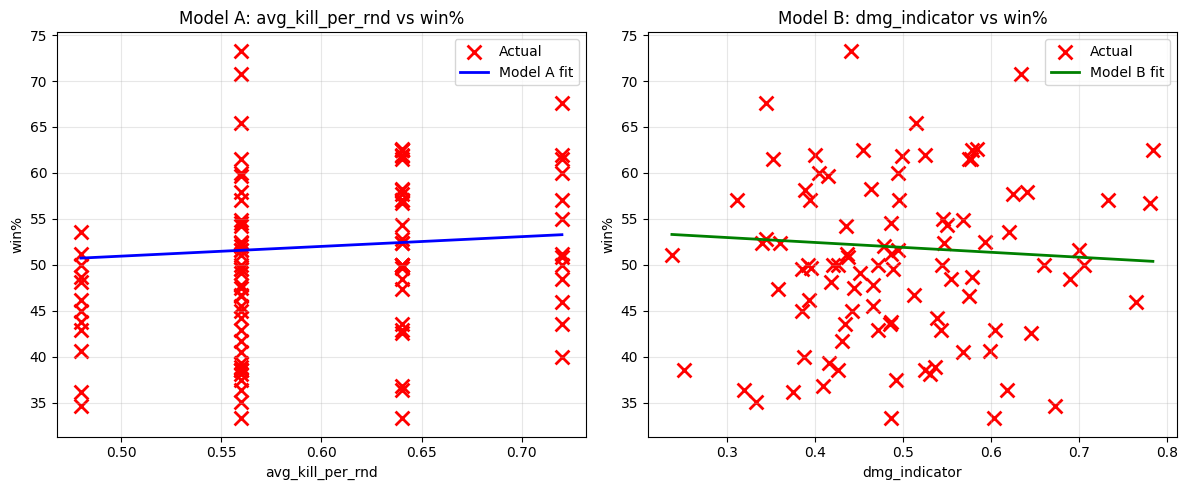

In [60]:
# ...existing code...

# Determine which models are available
models = {}
try:
    models["Model A"] = model_A
except NameError:
    pass

try:
    models["Model B"] = model_B
except NameError:
    pass

if not models or not test_data:
    print("No models or test data available.")
else:
    fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))
    
    if len(models) == 1:
        axes = [axes]
    
    colors = {"Model A": "blue", "Model B": "green"}
    
    for idx, (model_name, model) in enumerate(models.items()):
        if model_name not in test_data:
            continue
        
        ax = axes[idx]
        x_test = test_data[model_name]["x_test"]
        y_test = test_data[model_name]["y_test"]
        x_col = test_data[model_name]["x_col"]
        
        # Sort for clean line
        order = np.argsort(x_test.flatten())
        x_sorted = x_test.flatten()[order]
        
        # Scatter plot
        ax.scatter(x_test, y_test, color="red", marker="x", label="Actual", s=100, linewidth=2)
        
        # Regression line
        y_pred = model.predict(x_test)
        y_pred_sorted = y_pred[order]
        ax.plot(x_sorted, y_pred_sorted, color=colors[model_name], linewidth=2, label=f"{model_name} fit")
        
        # Labels
        ax.set_title(f"{model_name}: {x_col} vs {y_col}")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ...existing code...

### Evaluation Model score

In [61]:
# ...existing code...

# Evaluation Model score (per-model test data)
for model_name, model in models.items():
    if model_name not in test_data:
        print(f"{model_name}: no prepared test data")
        continue

    x_t = test_data[model_name]["x_test"]
    y_t = test_data[model_name]["y_test"]
    score = model.score(x_t, y_t)
    print(
        f"{model_name} test ({test_data[model_name]['x_col']} -> {y_col}): {score:.4f}"
    )

# ...existing code...

Model A test (avg_kill_per_rnd -> win%): -0.0037
Model B test (dmg_indicator -> win%): -0.0594
